In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, LassoCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

df=pd.read_csv("New 1000 Sales Records.csv")
df.head()
df.tail()
df.dtypes
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Region           1000 non-null   object 
 1   Country          1000 non-null   object 
 2   Item Type        1000 non-null   object 
 3   Sales Channel    1000 non-null   object 
 4   Order Priority   1000 non-null   object 
 5   Order Date       1000 non-null   object 
 6   Order ID         1000 non-null   int64  
 7   Ship Date        1000 non-null   object 
 8   Units Sold       1000 non-null   int64  
 9   Unit Price       1000 non-null   float64
 10  Unit Cost        1000 non-null   float64
 11  Total Revenue    1000 non-null   float64
 12  Total Cost       1000 non-null   float64
 13  Total Profit     1000 non-null   float64
 14  Order year       1000 non-null   int64  
 15  Order Month      1000 non-null   int64  
 16  Order Weekday    1000 non-null   object 
 17  Unit Margin    

,Order ID,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,Order year,Order Month,Unit Margin
count,1.000000e+03,1000.000000,1000.00000,1000.000000,1.000000e+03,1.000000e+03,1.000000e+03,1000.000000,1000.000000,1000.000000
mean,5.496813e+08,5053.988000,262.10684,184.965110,1.327322e+06,9.361192e+05,3.912026e+05,2013.234000,6.348000,77.141730
std,2.571334e+08,2901.375317,216.02106,175.289311,1.486515e+06,1.162571e+06,3.836402e+05,2.164238,3.472889,51.610854
min,1.029280e+08,13.000000,9.33000,6.920000,2.043250e+03,1.416750e+03,5.326100e+02,2010.000000,1.000000,2.410000
25%,3.280740e+08,2420.250000,81.73000,56.670000,2.811919e+05,1.649319e+05,9.837612e+04,2011.000000,3.000000,25.060000
50%,5.566097e+08,5184.000000,154.06000,97.440000,7.549392e+05,4.647261e+05,2.772260e+05,2013.000000,6.000000,63.130000
75%,7.696945e+08,7536.750000,421.89000,263.330000,1.733503e+06,1.141750e+06,5.484568e+05,2015.000000,9.000000,95.860000
max,9.955298e+08,9998.000000,668.27000,524.960000,6.617210e+06,5.204978e+06,1.726181e+06,2017.000000,12.000000,173.870000


In [75]:
print(df.isnull().sum())

Region             0
Country            0
Item Type          0
Sales Channel      0
Order Priority     0
Order Date         0
Order ID           0
Ship Date          0
Units Sold         0
Unit Price         0
Unit Cost          0
Total Revenue      0
Total Cost         0
Total Profit       0
Order year         0
Order Month        0
Order Weekday      0
Unit Margin        0
Order_Ship_Days    0
dtype: int64


In [76]:
df=df.drop(columns=["Order ID"])

In [77]:
df=pd.get_dummies(df,columns=["Region","Country","Item Type","Order Priority","Order Weekday"])

In [78]:
df.head()

,Sales Channel,Order Date,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,Order year,...,Order Priority_H,Order Priority_L,Order Priority_M,Order Weekday_fri,Order Weekday_mon,Order Weekday_sat,Order Weekday_sun,Order Weekday_thur,Order Weekday_tue,Order Weekday_wed
0,Offline,2014-10-18,2014-10-31,8446,437.20,263.33,3692591.20,2224085.18,1468506.02,2014,...,False,False,True,True,False,False,False,False,False,False
1,Online,2011-11-07,2011-12-08,3018,154.06,90.93,464953.08,274426.74,190526.34,2011,...,False,False,True,False,False,False,True,False,False,False
2,Offline,2016-10-31,2016-12-09,1517,255.28,159.42,387259.76,241840.14,145419.62,2016,...,False,False,False,False,False,False,True,False,False,False
3,Offline,2010-04-10,2010-05-12,3322,205.70,117.11,683335.40,389039.42,294295.98,2010,...,False,False,False,True,False,False,False,False,False,False
4,Offline,2011-08-16,2011-08-31,9845,9.33,6.92,91853.85,68127.40,23726.45,2011,...,True,False,False,False,True,False,False,False,False,False


In [79]:
df["Order Date"]=pd.to_datetime(df["Order Date"])
df["Ship Date"]=pd.to_datetime(df["Ship Date"])

In [80]:
df.dtypes
df.tail()

,Sales Channel,Order Date,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,Order year,...,Order Priority_H,Order Priority_L,Order Priority_M,Order Weekday_fri,Order Weekday_mon,Order Weekday_sat,Order Weekday_sun,Order Weekday_thur,Order Weekday_tue,Order Weekday_wed
995,Offline,2010-04-18,2010-04-25,6524,152.58,97.44,995431.92,635698.56,359733.36,2010,...,False,False,False,False,False,True,False,False,False,False
996,Offline,2011-08-01,2011-09-07,288,255.28,159.42,73520.64,45912.96,27607.68,2011,...,True,False,False,False,False,False,True,False,False,False
997,Online,2011-05-12,2011-06-28,9556,154.06,90.93,1472197.36,868927.08,603270.28,2011,...,False,False,False,False,False,False,False,False,False,True
998,Offline,2016-01-25,2016-02-14,9801,668.27,502.54,6549714.27,4925394.54,1624319.73,2016,...,False,True,False,False,False,False,True,False,False,False
999,Offline,2014-04-10,2014-05-08,3528,205.70,117.11,725709.60,413164.08,312545.52,2014,...,False,False,False,False,False,False,False,False,False,True


In [81]:
df['year_order']=df['Order Date'].dt.year
df['month_order']=df['Order Date'].dt.month
df['day_order']=df['Order Date'].dt.day
df['year_ship']=df['Order Date'].dt.year
df['month_ship']=df['Order Date'].dt.month
df['day_ship']=df['Order Date'].dt.day
df=df.drop(columns=["Order Date","Ship Date"])
df.tail()

,Sales Channel,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,Order year,Order Month,Unit Margin,...,Order Weekday_sun,Order Weekday_thur,Order Weekday_tue,Order Weekday_wed,year_order,month_order,day_order,year_ship,month_ship,day_ship
995,Offline,6524,152.58,97.44,995431.92,635698.56,359733.36,2010,4,55.14,...,False,False,False,False,2010,4,18,2010,4,18
996,Offline,288,255.28,159.42,73520.64,45912.96,27607.68,2011,8,95.86,...,True,False,False,False,2011,8,1,2011,8,1
997,Online,9556,154.06,90.93,1472197.36,868927.08,603270.28,2011,5,63.13,...,False,False,False,True,2011,5,12,2011,5,12
998,Offline,9801,668.27,502.54,6549714.27,4925394.54,1624319.73,2016,1,165.73,...,True,False,False,False,2016,1,25,2016,1,25
999,Offline,3528,205.70,117.11,725709.60,413164.08,312545.52,2014,4,88.59,...,False,False,False,True,2014,4,10,2014,4,10


In [82]:
df["Order_Ship_Days"]=df["Order_Ship_Days"].str.replace(" days","",regex=False).astype(int)

In [83]:
df["Sales Channel"]=df["Sales Channel"].map({"Offline":0,"Online":1})

In [84]:
df.tail()

,Sales Channel,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,Order year,Order Month,Unit Margin,...,Order Weekday_sun,Order Weekday_thur,Order Weekday_tue,Order Weekday_wed,year_order,month_order,day_order,year_ship,month_ship,day_ship
995,0,6524,152.58,97.44,995431.92,635698.56,359733.36,2010,4,55.14,...,False,False,False,False,2010,4,18,2010,4,18
996,0,288,255.28,159.42,73520.64,45912.96,27607.68,2011,8,95.86,...,True,False,False,False,2011,8,1,2011,8,1
997,1,9556,154.06,90.93,1472197.36,868927.08,603270.28,2011,5,63.13,...,False,False,False,True,2011,5,12,2011,5,12
998,0,9801,668.27,502.54,6549714.27,4925394.54,1624319.73,2016,1,165.73,...,True,False,False,False,2016,1,25,2016,1,25
999,0,3528,205.70,117.11,725709.60,413164.08,312545.52,2014,4,88.59,...,False,False,False,True,2014,4,10,2014,4,10


Text(0, 0.5, 'Frequency')

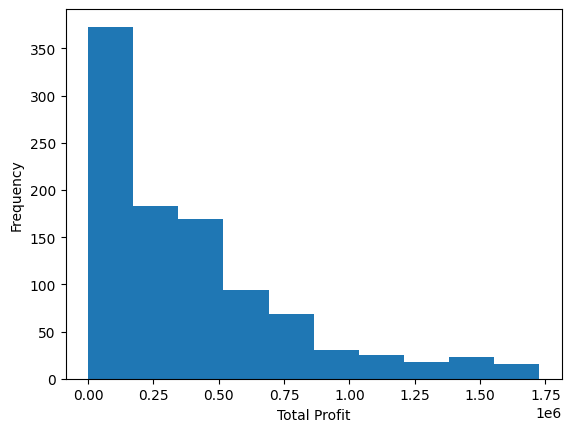

In [85]:
plt.hist(df['Total Profit'])
plt.xlabel('Total Profit')
plt.ylabel('Frequency')

Text(0, 0.5, 'Total Cost')

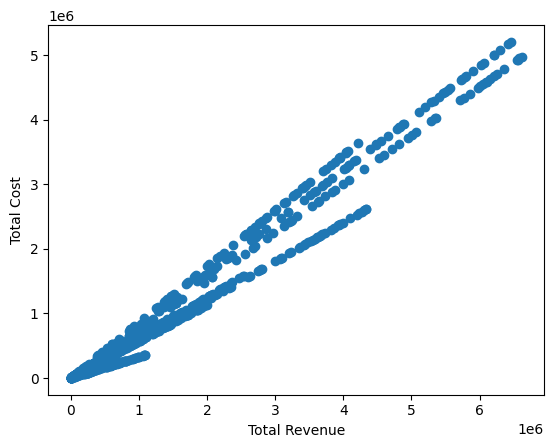

In [86]:
plt.scatter(df["Total Revenue"],df["Total Cost"])
plt.xlabel("Total Revenue")
plt.ylabel("Total Cost")

In [87]:
# plt.figure(figsize=(10, 6))
# sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
# plt.show()

In [88]:
X=df.drop(columns=["Total Profit"],axis=1)
y=df["Total Profit"]

In [89]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [90]:
scaler=StandardScaler()
X_train_trans=scaler.fit_transform(X_train)
X_test_trans=scaler.transform(X_test)

In [91]:
lg=LinearRegression()
lg.fit(X_train,y_train)
y_pred=lg.predict(X_test)

print("R2: ",r2_score(y_test,y_pred))
print("MSE: ",mean_squared_error(y_test,y_pred))
print("MAE: ", mean_absolute_error(y_test,y_pred))

R2:  1.0
MSE:  9.012961549285409e-19
MAE:  7.641426691407105e-10


In [92]:
ridge_model=Ridge(alpha=1)
ridge_model.fit(X_train,y_train)
y_pred2=ridge_model.predict(X_test)

print("R2: ",r2_score(y_test,y_pred2))
print("MSE: ",mean_squared_error(y_test,y_pred2))
print("MAE: ", mean_absolute_error(y_test,y_pred2))

R2:  1.0
MSE:  3.3160744485277432e-15
MAE:  4.2028912048408526e-08


In [93]:
lasso_model=LassoCV()
lasso_model.fit(X_train,y_train)
y_pred3=lasso_model.predict(X_test)

print("R2: ",r2_score(y_test,y_pred3))
print("MSE: ",mean_squared_error(y_test,y_pred3))
print("MAE: ", mean_absolute_error(y_test,y_pred3))

R2:  0.9998474476497534
MSE:  19672045.43428526
MAE:  3261.173891402706
